# 01 · Setup & EDA

First notebook in the lab. Goals:

1. Confirm the environment works and the data layer loads.
2. Explore the unified dataset — interactions, the **social graph**, item text, and image-stand-in vectors.
3. Build intuition about sparsity and the long tail, which motivate every model choice later.

> Runs on **synthetic** data out of the box (no download). Once you build a real Yelp subset into `data/processed/`, the same code uses it instead.

In [1]:
import sys
from pathlib import Path

# Make the src/ package importable from the notebooks/ folder.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.recsys.data import load_dataset

ds = load_dataset()  # auto-generates synthetic data if none present
print(ds.summary())

Matplotlib is building the font cache; this may take a moment.


Dataset(users=800, items=400, interactions=19,847, density=6.2022%, social_edges=4,619, has_images=True)


## Peek at each signal

The whole point of Path A: interactions, social, text, and images live in one dataset.

In [2]:
print("Interactions:"); display(ds.interactions.head())
print("Items (note the text column used by the text/LLM module):"); display(ds.items.head())
print("Social edges (user_id <-> friend_id):"); display(ds.social.head())
print("Image-stand-in vectors shape:", None if ds.item_image_vectors is None else ds.item_image_vectors.shape)

Interactions:


,user_id,item_id,rating,timestamp
0,u_00000,b_00398,5,2022-02-11
1,u_00000,b_00288,5,2022-08-01
2,u_00000,b_00084,5,2022-03-18
3,u_00000,b_00187,5,2021-12-01
4,u_00000,b_00035,5,2021-01-15


Items (note the text column used by the text/LLM module):


,item_id,name,categories,text
0,b_00000,Business 0,"vegan, pizza, noodles",A popular spot known for vegan and pizza. Gues...
1,b_00001,Business 1,"cocktails, seafood, vegan",A popular spot known for cocktails and seafood...
2,b_00002,Business 2,"burgers, dessert, wine",A popular spot known for burgers and dessert. ...
3,b_00003,Business 3,"thai, seafood, steakhouse",A popular spot known for thai and seafood. Gue...
4,b_00004,Business 4,"cocktails, burgers, coffee",A popular spot known for cocktails and burgers...


Social edges (user_id <-> friend_id):


,user_id,friend_id
0,u_00632,u_00734
1,u_00095,u_00795
2,u_00255,u_00784
3,u_00101,u_00689
4,u_00163,u_00521


Image-stand-in vectors shape: (400, 32)


## Sparsity & the long tail

Two facts drive every design decision in recsys: the user–item matrix is
extremely **sparse**, and interactions follow a **long-tail** (a few items get
most of the activity). This is why popularity is a strong baseline and why cold
start is hard.

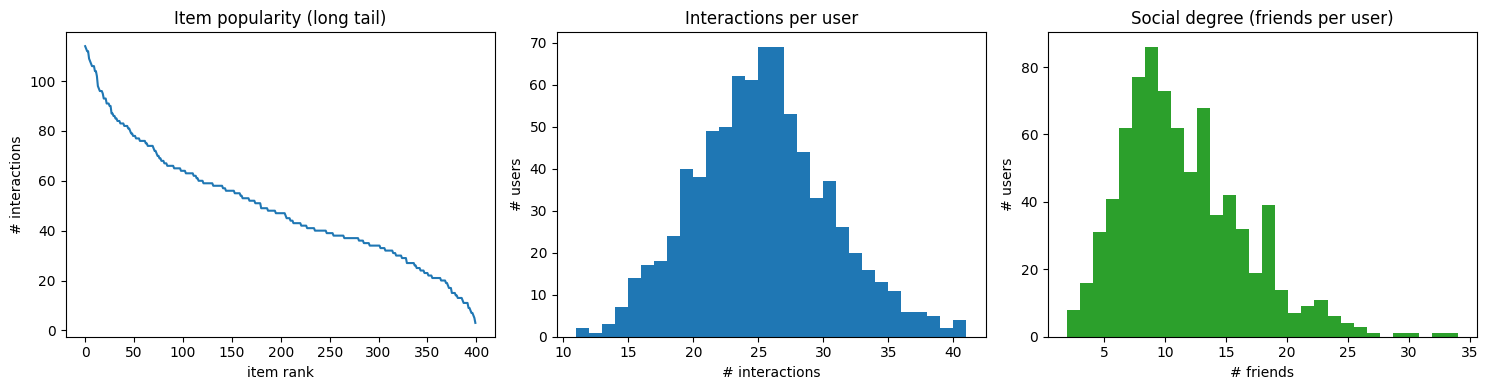

Matrix density: 6.2022%  (i.e. ~93.80% of the matrix is empty)


In [3]:
from src.recsys.config import settings

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Item popularity (long tail)
item_counts = ds.interactions[settings.item_col].value_counts().values
axes[0].plot(range(len(item_counts)), item_counts)
axes[0].set(title="Item popularity (long tail)", xlabel="item rank", ylabel="# interactions")

# Interactions per user
user_counts = ds.interactions[settings.user_col].value_counts().values
axes[1].hist(user_counts, bins=30)
axes[1].set(title="Interactions per user", xlabel="# interactions", ylabel="# users")

# Friends per user (social graph degree)
if len(ds.social):
    deg = pd.concat([ds.social[settings.user_col], ds.social["friend_id"]]).value_counts().values
    axes[2].hist(deg, bins=30, color="tab:green")
axes[2].set(title="Social degree (friends per user)", xlabel="# friends", ylabel="# users")

plt.tight_layout(); plt.show()

density = ds.n_interactions / (ds.n_users * ds.n_items)
print(f"Matrix density: {density:.4%}  (i.e. ~{100*(1-density):.2f}% of the matrix is empty)")

**Next:** open `02_baselines.ipynb` to run popularity, item-CF, and ALS on a proper temporal split and compare them with ranking metrics.